In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [18]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
df = pd.read_csv(url)

df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


In [4]:
df.describe()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.00000,200.000000,200.000000,200.000000,200.00000,...,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,35.505000,41.165000,11.650000,75.130000,2.82500,10.22500,0.425000,0.705000,0.290000,11.78925,...,0.275000,0.440000,0.45500,0.460000,0.440000,2.193285,3.229185,3.951015,2.475000,0.290000
std,21.640971,13.076803,10.158419,128.430468,1.28555,8.95743,0.495584,0.457187,0.454901,9.88725,...,0.447635,0.497633,0.49922,0.499648,0.497633,0.731282,0.281019,0.752553,1.079445,0.454901
min,1.000000,19.000000,0.000000,9.000000,1.00000,0.00000,0.000000,0.000000,0.000000,1.10000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.095000,1.749000,2.197000,1.000000,0.000000
25%,16.750000,31.000000,3.000000,31.000000,2.00000,3.00000,0.000000,0.000000,0.000000,5.53750,...,0.000000,0.000000,0.00000,0.000000,0.000000,1.711750,3.226500,3.434000,2.000000,0.000000
50%,33.500000,40.000000,9.000000,48.000000,3.00000,7.50000,0.000000,1.000000,0.000000,8.25000,...,0.000000,0.000000,0.00000,0.000000,0.000000,2.110000,3.240000,3.871000,2.000000,0.000000
75%,55.250000,51.000000,18.000000,80.000000,4.00000,17.00000,1.000000,1.000000,1.000000,14.30000,...,1.000000,1.000000,1.00000,1.000000,1.000000,2.660000,3.240000,4.382000,3.000000,1.000000
max,72.000000,76.000000,48.000000,1668.000000,5.00000,44.00000,1.000000,1.000000,1.000000,62.30000,...,1.000000,1.000000,1.00000,1.000000,1.000000,4.132000,4.227000,7.419000,4.000000,1.000000


In [19]:
df.columns

Index(['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip',
       'callcard', 'wireless', 'longmon', 'tollmon', 'equipmon', 'cardmon',
       'wiremon', 'longten', 'tollten', 'cardten', 'voice', 'pager',
       'internet', 'callwait', 'confer', 'ebill', 'loglong', 'logtoll',
       'lninc', 'custcat', 'churn'],
      dtype='str')

To Find relevant features do the following thing

In [20]:
import statsmodels.api as sm

X = sm.add_constant(df.drop(columns=['churn']))
model = sm.Logit(df['churn'], X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.391309
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                  200
Model:                          Logit   Df Residuals:                      172
Method:                           MLE   Df Model:                           27
Date:                Thu, 06 Aug 2026   Pseudo R-squ.:                  0.3501
Time:                        14:34:26   Log-Likelihood:                -78.262
converged:                       True   LL-Null:                       -120.43
Covariance Type:            nonrobust   LLR p-value:                 8.179e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3628      3.839      0.876      0.381      -4.161      10.887
tenure        -0.0652      0.

Top Features are from tenure to equip

In [21]:
df = df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
df['churn'] = df['churn'].astype('int')
df.dtypes

tenure     float64
age        float64
address    float64
income     float64
ed         float64
employ     float64
equip      float64
churn        int64
dtype: object

In [22]:
target = df['churn']
features = df.drop(columns='churn')
features.columns


Index(['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip'], dtype='str')

In Classification, Boxplot is better as scatterplot shows just 2 rows

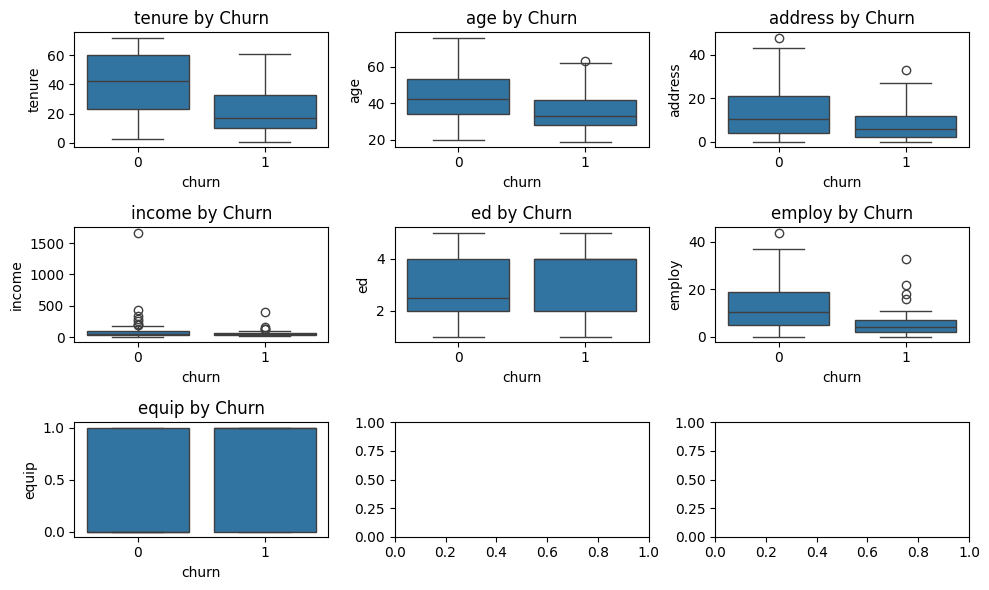

In [36]:
fig, axes = plt.subplots(3,3,figsize=(10,6))
axes=axes.flatten()
for ax,x in zip(axes,features):
    sns.boxplot(x=df['churn'], y=df[x], ax=ax)
    ax.set_title(f"{x} by Churn")
    
plt.tight_layout()
plt.show()

- Tenure, Age, Employ are Strong signals
- Address might also seem strong but boxes overlap
- Income cant be judged since most are outliers
- Equip is useless
- Other are weak indicators
- But these findings are only by eyeballing 1 type of plot so dont just really drop them now

In [23]:
features.sample(5)

,tenure,age,address,income,ed,employ,equip
32,22.0,34.0,1.0,46.0,3.0,1.0,1.0
89,7.0,23.0,3.0,27.0,2.0,1.0,0.0
143,63.0,37.0,1.0,45.0,4.0,9.0,1.0
58,32.0,27.0,3.0,91.0,4.0,1.0,1.0
145,68.0,42.0,16.0,89.0,4.0,12.0,1.0


In [24]:
target.sample(5)

64     0
159    1
39     0
115    1
84     1
Name: churn, dtype: int64

In [26]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

In [53]:
scaler = StandardScaler()
x_scaled_train = scaler.fit_transform(x_train)
x_scaled_test = scaler.transform(x_test)

In [54]:
model = LogisticRegression()
model.fit(x_scaled_train, y_train)
y_pred = model.predict(x_scaled_test)
y_pred

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [55]:
y_pred_prob = model.predict_proba(x_scaled_test)
y_pred_prob

array([[0.58503504, 0.41496496],
       [0.18487774, 0.81512226],
       [0.82241292, 0.17758708],
       [0.75056567, 0.24943433],
       [0.84382663, 0.15617337],
       [0.28696902, 0.71303098],
       [0.9904343 , 0.0095657 ],
       [0.64391642, 0.35608358],
       [0.5079421 , 0.4920579 ],
       [0.9622482 , 0.0377518 ],
       [0.94752581, 0.05247419],
       [0.94507141, 0.05492859],
       [0.80989547, 0.19010453],
       [0.97353418, 0.02646582],
       [0.36496883, 0.63503117],
       [0.91637635, 0.08362365],
       [0.73633475, 0.26366525],
       [0.41899961, 0.58100039],
       [0.77861907, 0.22138093],
       [0.67753044, 0.32246956],
       [0.96296643, 0.03703357],
       [0.49556218, 0.50443782],
       [0.23321225, 0.76678775],
       [0.47205421, 0.52794579],
       [0.81513886, 0.18486114],
       [0.97903336, 0.02096664],
       [0.45837399, 0.54162601],
       [0.95201753, 0.04798247],
       [0.97876317, 0.02123683],
       [0.87518174, 0.12481826],
       [0.

Our Purpose is to find how to make customer churn = 1. So examine each feature

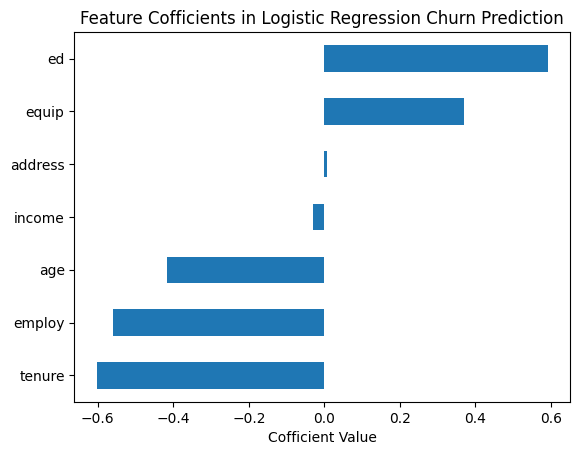

In [56]:
coffs = pd.Series(model.coef_[0], index=features.columns)
coffs.sort_values().plot(kind='barh')
plt.title('Feature Cofficients in Logistic Regression Churn Prediction')
plt.xlabel('Cofficient Value')
plt.show()

Increaing Equip and Ed means the churn return is higher

In [57]:
log_loss(y_test, y_pred_prob)

0.5184488485693809

In [59]:
from sklearn.metrics import accuracy_score
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred),2)}%")

Accuracy: 71.67%
